In [1]:
import sys
sys.path.append('../../src')  # repo-relative: notebooks/pipeline/../../src
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from config import *

train_df = pd.read_csv(os.path.join(PROC_DIR, 'train_step06.csv'))
test_df = pd.read_csv(os.path.join(PROC_DIR, 'test_step06.csv'))

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

print("\nColumns in train:")
print(train_df.columns.tolist())


Train shape: (77299, 22)
Test shape: (41778, 21)

Columns in train:
['day', 'demand', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'hour', 'minute', 'road_type_ord', 'weather_severity', 'latitude', 'longitude', 'geohash_target_enc', 'geohash_prefix_enc', 'hour_sin', 'hour_cos', 'is_peak_hour', 'is_business_hour', 'is_night', 'hour_squared', 'road_capacity', 'road_combo']


In [2]:
# Calculate mean demand per road_combo category
# Order the 4 combos by their own mean demand rather than picking an order by
# hand — this is the same "let the data set the order" logic used for
# RoadType/Weather in step03, just derived here instead of hardcoded in config
# since road_combo doesn't exist until this cell.
combo_means = train_df.groupby('road_combo')['demand'].mean().sort_values()

# Extract categories ordered from lowest to highest mean demand
ordered_categories = [combo_means.index.tolist()]

# Initialize encoder with specified order
encoder = OrdinalEncoder(categories=ordered_categories)

# Fit on train and transform
train_df['road_combo'] = encoder.fit_transform(train_df[['road_combo']])
test_df['road_combo'] = encoder.transform(test_df[['road_combo']])

print("Ordinal Encoder Mapping:")
for i, cat in enumerate(ordered_categories[0]):
    print(f"  {cat} -> {i} (Mean Demand: {combo_means.loc[cat]:.2f})")

print(f"\nNulls in Train road_combo: {train_df['road_combo'].isnull().sum()}")


Ordinal Encoder Mapping:
  0_0 -> 0 (Mean Demand: 0.06)
  0_1 -> 1 (Mean Demand: 0.09)
  1_1 -> 2 (Mean Demand: 0.10)
  1_0 -> 3 (Mean Demand: 0.61)

Nulls in Train road_combo: 0


hour_x_roadtype: min=0.0, max=46.0, mean=1.23

Mean demand per hour_x_roadtype:
hour_x_roadtype
0.0    0.060124
1.0    0.274616
2.0    0.442439
3.0    0.264126
4.0    0.393339
Name: demand, dtype: float64


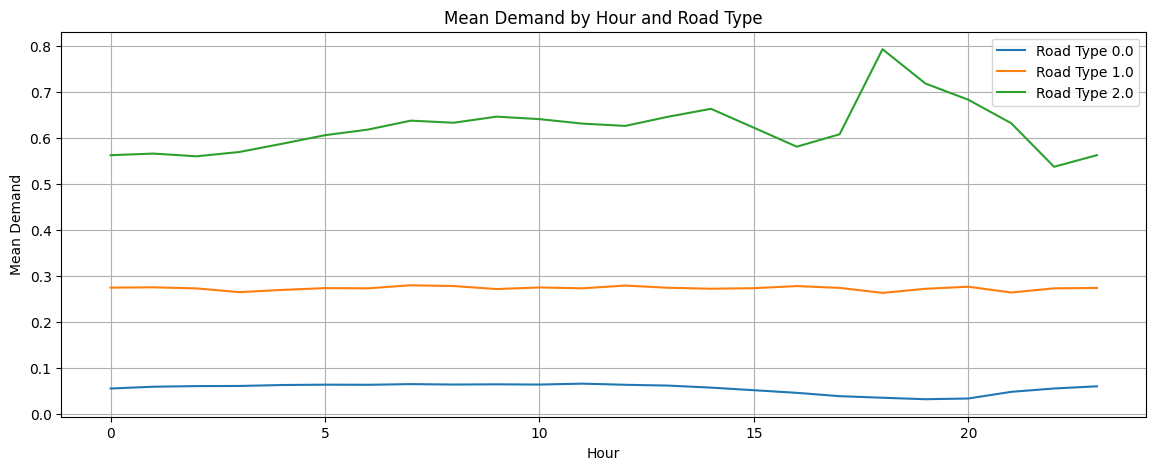

In [3]:
import matplotlib.pyplot as plt

# hour x road_type: the multivariate EDA showed the rush-hour spike is a
# highway phenomenon — residential streets stay flat all day. hour and
# road_type_ord on their own can't express "the effect of hour depends on
# road_type"; their product can. This turned out to be the single most
# useful interaction feature by feature importance in step10.
train_df['hour_x_roadtype'] = np.multiply(train_df['hour'], train_df['road_type_ord'])
test_df['hour_x_roadtype'] = np.multiply(test_df['hour'], test_df['road_type_ord'])

print(f"hour_x_roadtype: min={train_df['hour_x_roadtype'].min()}, max={train_df['hour_x_roadtype'].max()}, mean={train_df['hour_x_roadtype'].mean():.2f}")

print("\nMean demand per hour_x_roadtype:")
print(train_df.groupby('hour_x_roadtype')['demand'].mean().head())

plt.figure(figsize=(14, 5))
for road_type in sorted(train_df['road_type_ord'].unique()):
    subset = train_df[train_df['road_type_ord'] == road_type]
    hourly_mean = subset.groupby('hour')['demand'].mean()
    plt.plot(hourly_mean.index, hourly_mean.values, label=f'Road Type {road_type}')

plt.title('Mean Demand by Hour and Road Type')
plt.xlabel('Hour')
plt.ylabel('Mean Demand')
plt.legend()
plt.grid(True)
os.makedirs(MULTIVARIATE_PLOTS_DIR, exist_ok=True)
plt.savefig(os.path.join(MULTIVARIATE_PLOTS_DIR, 'hour_x_roadtype_interaction.png'))
plt.show()


In [4]:
train_df['geo_hour_sin'] = np.multiply(train_df['geohash_target_enc'], train_df['hour_sin'])
test_df['geo_hour_sin'] = np.multiply(test_df['geohash_target_enc'], test_df['hour_sin'])

print(f"geo_hour_sin: min={train_df['geo_hour_sin'].min():.4f}, max={train_df['geo_hour_sin'].max():.4f}, mean={train_df['geo_hour_sin'].mean():.4f}")

corr = train_df[['geo_hour_sin', 'demand']].corr().iloc[0, 1]
print(f"\nCorrelation with demand: {corr:.4f}")


geo_hour_sin: min=-0.9630, max=0.9603, mean=0.0089

Correlation with demand: 0.2873


road_x_weather: min=0.0, max=6.0, mean=0.16

Mean demand per road_x_weather (sorted):
road_x_weather
0.0    0.072102
1.0    0.271469
2.0    0.426319
3.0    0.275687
4.0    0.602992
6.0    0.601688
Name: demand, dtype: float64


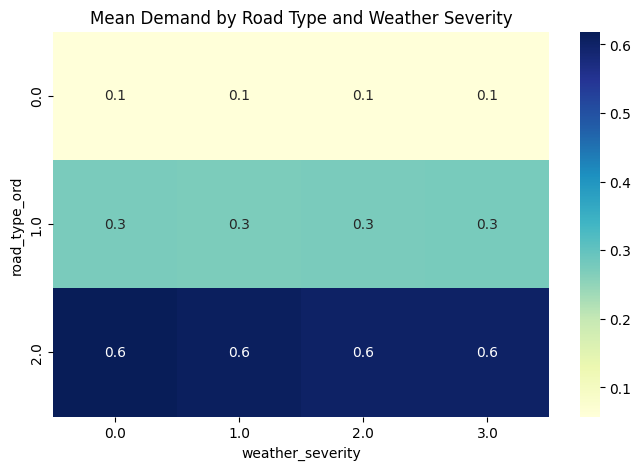

In [5]:
import seaborn as sns

train_df['road_x_weather'] = np.multiply(train_df['road_type_ord'], train_df['weather_severity'])
test_df['road_x_weather'] = np.multiply(test_df['road_type_ord'], test_df['weather_severity'])

print(f"road_x_weather: min={train_df['road_x_weather'].min()}, max={train_df['road_x_weather'].max()}, mean={train_df['road_x_weather'].mean():.2f}")

print("\nMean demand per road_x_weather (sorted):")
print(train_df.groupby('road_x_weather')['demand'].mean().sort_index())

pivot_df = train_df.pivot_table(values='demand', index='road_type_ord', columns='weather_severity', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Mean Demand by Road Type and Weather Severity')
os.makedirs(MULTIVARIATE_PLOTS_DIR, exist_ok=True)
plt.savefig(os.path.join(MULTIVARIATE_PLOTS_DIR, 'road_x_weather_interaction.png'))
plt.show()


In [6]:
# geo_x_roadtype's 0.88 correlation with demand looks suspiciously high for
# an engineered feature — worth being upfront about why: geohash_target_enc
# is *already* a leave-one-out estimate of each location's mean demand, so
# anything multiplied by it inherits a chunk of that correlation for free.
# This isn't leakage (LOO still excludes each row's own value), but it does
# mean this feature's importance in the model partly reflects geohash_target_enc's
# own signal, not purely new information from road_type.
train_df['geo_x_roadtype'] = np.multiply(train_df['geohash_target_enc'], train_df['road_type_ord'])
test_df['geo_x_roadtype'] = np.multiply(test_df['geohash_target_enc'], test_df['road_type_ord'])

print(f"geo_x_roadtype: min={train_df['geo_x_roadtype'].min():.4f}, max={train_df['geo_x_roadtype'].max():.4f}, mean={train_df['geo_x_roadtype'].mean():.4f}")

corr = train_df[['geo_x_roadtype', 'demand']].corr().iloc[0, 1]
print(f"\nCorrelation with demand: {corr:.4f}")


geo_x_roadtype: min=0.0000, max=1.9274, mean=0.0528

Correlation with demand: 0.8760


In [7]:
train_df['geo_x_weather'] = np.multiply(train_df['geohash_target_enc'], train_df['weather_severity'])
test_df['geo_x_weather'] = np.multiply(test_df['geohash_target_enc'], test_df['weather_severity'])

print(f"geo_x_weather: min={train_df['geo_x_weather'].min():.4f}, max={train_df['geo_x_weather'].max():.4f}, mean={train_df['geo_x_weather'].mean():.4f}")

corr = train_df[['geo_x_weather', 'demand']].corr().iloc[0, 1]
print(f"\nCorrelation with demand: {corr:.4f}")


geo_x_weather: min=0.0000, max=2.8861, mean=0.1035

Correlation with demand: 0.5295


In [8]:
train_df['lanes_x_weather'] = np.multiply(train_df['NumberofLanes'], train_df['weather_severity'])
test_df['lanes_x_weather'] = np.multiply(test_df['NumberofLanes'], test_df['weather_severity'])

print(f"lanes_x_weather: min={train_df['lanes_x_weather'].min()}, max={train_df['lanes_x_weather'].max()}, mean={train_df['lanes_x_weather'].mean():.2f}")

print("\nMean demand per lanes_x_weather (sorted):")
print(train_df.groupby('lanes_x_weather')['demand'].mean().sort_index())


lanes_x_weather: min=0.0, max=15.0, mean=2.21

Mean demand per lanes_x_weather (sorted):
lanes_x_weather
0.0     0.094330
1.0     0.088768
2.0     0.082739
3.0     0.080854
4.0     0.097423
5.0     0.606944
6.0     0.076847
8.0     0.600584
9.0     0.076702
10.0    0.605676
12.0    0.598819
15.0    0.582502
Name: demand, dtype: float64


In [9]:
train_df['geo_x_peak'] = np.multiply(train_df['geohash_target_enc'], train_df['is_peak_hour'])
test_df['geo_x_peak'] = np.multiply(test_df['geohash_target_enc'], test_df['is_peak_hour'])

print(f"geo_x_peak: min={train_df['geo_x_peak'].min():.4f}, max={train_df['geo_x_peak'].max():.4f}, mean={train_df['geo_x_peak'].mean():.4f}")

peak_mean = train_df[train_df['geo_x_peak'] > 0]['demand'].mean()
non_peak_mean = train_df[train_df['geo_x_peak'] == 0]['demand'].mean()

print(f"\nMean demand for geo_x_peak > 0: {peak_mean:.4f}")
print(f"Mean demand for geo_x_peak == 0: {non_peak_mean:.4f}")


geo_x_peak: min=0.0000, max=0.9635, mean=0.0224

Mean demand for geo_x_peak > 0: 0.0872
Mean demand for geo_x_peak == 0: 0.0957


In [10]:
train_df['temp_x_weather'] = np.multiply(train_df['Temperature'], train_df['weather_severity'])
test_df['temp_x_weather'] = np.multiply(test_df['Temperature'], test_df['weather_severity'])

print(f"temp_x_weather: min={train_df['temp_x_weather'].min():.4f}, max={train_df['temp_x_weather'].max():.4f}, mean={train_df['temp_x_weather'].mean():.4f}")

corr = train_df[['temp_x_weather', 'demand']].corr().iloc[0, 1]
print(f"\nCorrelation with demand: {corr:.4f}")


temp_x_weather: min=-44.8053, max=62.8031, mean=11.4974

Correlation with demand: -0.0003


In [11]:
interaction_features = [
    'hour_x_roadtype', 'geo_hour_sin', 'road_x_weather',
    'geo_x_roadtype', 'geo_x_weather', 'lanes_x_weather',
    'geo_x_peak', 'temp_x_weather'
]

summary = train_df[interaction_features].agg(['min', 'max', 'mean', lambda x: x.isnull().sum()]).T
summary.rename(columns={'<lambda>': 'null_count'}, inplace=True)

print("Interaction Features Summary:")
display(summary)

print(f"\nFull column list of train:")
print(train_df.columns.tolist())
print(f"Total columns: {len(train_df.columns)}")


Interaction Features Summary:


,min,max,mean,null_count
hour_x_roadtype,0.000000,46.000000,1.227170,0.0
geo_hour_sin,-0.963048,0.960337,0.008899,0.0
road_x_weather,0.000000,6.000000,0.156820,0.0
geo_x_roadtype,0.000000,1.927368,0.052754,0.0
geo_x_weather,0.000000,2.886124,0.103461,0.0
lanes_x_weather,0.000000,15.000000,2.213211,0.0
geo_x_peak,0.000000,0.963541,0.022371,0.0
temp_x_weather,-44.805290,62.803085,11.497387,0.0



Full column list of train:
['day', 'demand', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'hour', 'minute', 'road_type_ord', 'weather_severity', 'latitude', 'longitude', 'geohash_target_enc', 'geohash_prefix_enc', 'hour_sin', 'hour_cos', 'is_peak_hour', 'is_business_hour', 'is_night', 'hour_squared', 'road_capacity', 'road_combo', 'hour_x_roadtype', 'geo_hour_sin', 'road_x_weather', 'geo_x_roadtype', 'geo_x_weather', 'lanes_x_weather', 'geo_x_peak', 'temp_x_weather']
Total columns: 30


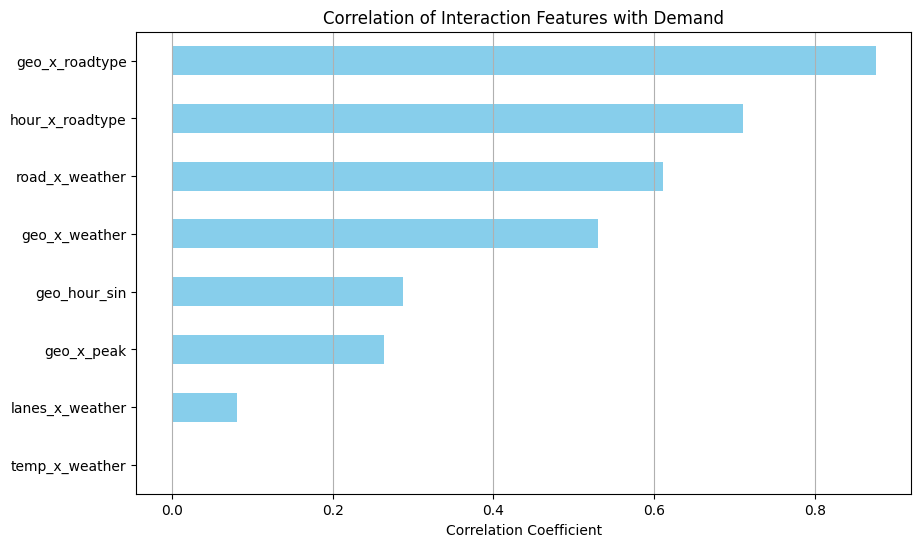

In [12]:
correlations = train_df[interaction_features + ['demand']].corr()['demand'].drop('demand')
correlations = correlations.reindex(correlations.abs().sort_values().index)

plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color='skyblue')
plt.title('Correlation of Interaction Features with Demand')
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x')
os.makedirs(MULTIVARIATE_PLOTS_DIR, exist_ok=True)
plt.savefig(os.path.join(MULTIVARIATE_PLOTS_DIR, 'interaction_correlations.png'))
plt.show()


In [13]:
train_df.to_csv(os.path.join(PROC_DIR, 'train_step07.csv'), index=False)
test_df.to_csv(os.path.join(PROC_DIR, 'test_step07.csv'), index=False)

print(f"Saved Train shape: {train_df.shape}")
print(f"Saved Test shape: {test_df.shape}")
print(f"Saved to: {os.path.join(PROC_DIR, 'train_step07.csv')}")
print(f"Saved to: {os.path.join(PROC_DIR, 'test_step07.csv')}")


Saved Train shape: (77299, 30)
Saved Test shape: (41778, 29)
Saved to: C:\TRAFFIC-DEMAND-FINAL\data\processed\train_step07.csv
Saved to: C:\TRAFFIC-DEMAND-FINAL\data\processed\test_step07.csv
